In [12]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

np.random.seed(42)
hours = np.random.uniform(1, 10, 100).reshape(-1, 1)
scores = 0*hours.flatten() + 20 + np.random.normal(0, 5, 100)

print("Hours Shape : ", hours.shape)
print("Scores Shape : ", scores.shape)
print("Score range :", scores.min().round(1),"to", scores.max().round(1))

Hours Shape :  (100, 1)
Scores Shape :  (100,)
Score range : 10.1 to 32.3


In [13]:
X_train, X_test, y_train, y_test = train_test_split(hours, scores, test_size=0.2, random_state=42)
model = LinearRegression()
model.fit(X_train, y_train)
print(f"Slope (m): {model.coef_[0]:.2f}")
print(f"Intercept (b): {model.intercept_:.2f}")


Slope (m): -0.22
Intercept (b): 20.94


In [14]:
y_pred = model.predict(X_test)
print(f"First five actual : {y_test[:5].round(1)}")
print(f"First five predicted : {y_pred[:5].round(1)}")

First five actual : [23.3 17.5 13.8 15.5 24. ]
First five predicted : [20.6 18.9 19.2 19.4 20.2]


In [15]:
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"R² Score: {r2:.4f}")

Mean Squared Error (MSE): 16.34
Root Mean Squared Error (RMSE): 4.04
R² Score: -0.0188


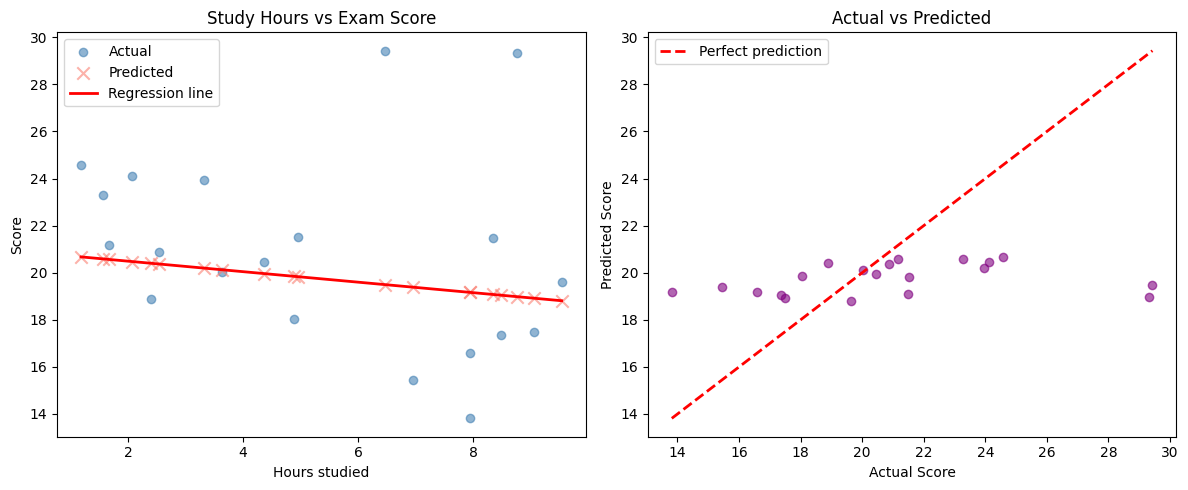

In [16]:
plt.figure(figsize=(12, 5))

 

# Plot 1: scatter with regression line

plt.subplot(1, 2, 1)

plt.scatter(X_test, y_test,  color='steelblue', alpha=0.6, label='Actual')

plt.scatter(X_test, y_pred,  color='salmon',    alpha=0.6, label='Predicted', marker='x', s=80)

# Draw the regression line

x_line = np.linspace(X_test.min(), X_test.max(), 100).reshape(-1,1)

plt.plot(x_line, model.predict(x_line), color='red', linewidth=2, label='Regression line')

plt.title('Study Hours vs Exam Score')

plt.xlabel('Hours studied')

plt.ylabel('Score')

plt.legend()

 

# Plot 2: actual vs predicted (perfect = diagonal line)

plt.subplot(1, 2, 2)

plt.scatter(y_test, y_pred, color='purple', alpha=0.6)

plt.plot([y_test.min(), y_test.max()],

         [y_test.min(), y_test.max()], 'r--', linewidth=2, label='Perfect prediction')

plt.title('Actual vs Predicted')

plt.xlabel('Actual Score')

plt.ylabel('Predicted Score')

plt.legend()

 

plt.tight_layout()

plt.savefig('regression_plots.png', dpi=150, bbox_inches='tight')

plt.show()